# Exploración Visual de los Datos Inmobiliarios

Este *Jupyter Notebook* tiene como objetivo explorar visualmente el dataset de propiedades que hemos limpiado y preparado hasta la fecha. Analizaremos distribuciones de precios, impacto de las características (como tener ascensor o piscina) y correlaciones matemáticas para preparar el terreno antes de entrenar nuestra Red Neuronal.

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo visual de las gráficas
sns.set_theme(style="whitegrid", palette="pastel")
plt.rcParams['figure.figsize'] = (12, 6)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [2]:
from IPython.display import display, HTML
import pandas as pd

# Cargamos el csv para asegurarnos de que el número esté siempre actualizado
try:
    df_temp = pd.read_csv('../data_pipeline/data/processed/propiedades_limpias.csv')
    total_propiedades = len(df_temp)
except Exception as e:
    total_propiedades = "Error"

html = f"""
<div style="background-color: #f8f9fa; border-left: 5px solid #2ecc71; padding: 15px; border-radius: 5px; font-family: Arial, sans-serif; box-shadow: 0 2px 4px rgba(0,0,0,0.1); display: inline-block;">
    <span style="font-size: 14px; color: #7f8c8d; text-transform: uppercase; font-weight: bold;">Tamaño del Dataset</span><br>
    <span style="font-size: 32px; font-weight: bold; color: #2c3e50;">{total_propiedades}</span>
    <span style="font-size: 16px; color: #2ecc71; font-weight: bold;"> inmuebles listos para entrenar</span>
</div>
"""
display(HTML(html))


### 1. Carga de los Datos Limpios

In [3]:
# Leer el CSV con las propiedades procesadas (Ruta ajustada a notebooks_v2)
df = pd.read_csv('../data_pipeline/data/processed/propiedades_limpias.csv')
print(f"Total de propiedades cargadas: {len(df)}")

# Ver las primeras filas
df.head()

Total de propiedades cargadas: 5031


,id_inmueble,url_origen,tipo_inmueble,barrio_limpio,planta_limpia,precio_limpio,m2,precio_m2,habitaciones,banos,...,img_url_1,img_url_2,img_url_3,img_url_4,img_url_5,local_img_1,local_img_2,local_img_3,local_img_4,local_img_5
0,2f76f644-77ff-480b-a5cb-fd2e9e374618,https://www.pisos.com/comprar/piso-trafalgar28...,Piso,Trafalgar,1.0,7000000.0,233.0,30042.92,2.0,4.0,...,https://fotos.imghs.net/xl-wp/1492/64166667897...,https://fotos.imghs.net/appswm-wp/1492/6416666...,https://map.imghs.net/Cache/Z2R35MG0MC1/2_350_...,NaN,NaN,raw\images\2f76f644-77ff-480b-a5cb-fd2e9e37461...,raw\images\2f76f644-77ff-480b-a5cb-fd2e9e37461...,raw\images\2f76f644-77ff-480b-a5cb-fd2e9e37461...,NaN,NaN
1,cc7c60b3-0d86-4826-8343-82f55cabfd6e,https://www.pisos.com/comprar/piso-guindalera2...,Piso,Guindalera,1.0,730000.0,91.0,8021.98,2.0,1.0,...,https://fotos.imghs.net/xl-wp/4400/63366549974...,https://fotos.imghs.net/prof-wp/logos/Logo_440...,https://fotos.imghs.net/appswm-wp/4400/6336654...,NaN,NaN,raw\images\cc7c60b3-0d86-4826-8343-82f55cabfd6...,raw\images\cc7c60b3-0d86-4826-8343-82f55cabfd6...,raw\images\cc7c60b3-0d86-4826-8343-82f55cabfd6...,NaN,NaN
2,f25c3a5e-9773-464f-b44f-528dfce4498c,https://www.pisos.com/comprar/piso-puente_de_v...,Piso,Portazgo,4.0,362000.0,94.0,3851.06,3.0,2.0,...,https://fotos.imghs.net/xl-wp/526710/634223457...,https://fotos.imghs.net/appswm-wp/526710/63422...,https://map.imghs.net/Cache/Z2R35MG0MC1/2_350_...,NaN,NaN,raw\images\f25c3a5e-9773-464f-b44f-528dfce4498...,raw\images\f25c3a5e-9773-464f-b44f-528dfce4498...,raw\images\f25c3a5e-9773-464f-b44f-528dfce4498...,NaN,NaN
3,f1ae3e26-731f-452b-9cf2-3d4518abfe90,https://www.pisos.com/comprar/piso-casco_histo...,Piso,Casco Histórico De Barajas,NaN,350000.0,75.0,4666.67,3.0,1.0,...,https://fotos.imghs.net/xl-wp/1005/245/1005_42...,https://fotos.imghs.net/appswm-wp/1005/245/100...,https://map.imghs.net/Cache/Z2R35MG0MC1/2_350_...,NaN,NaN,raw\images\f1ae3e26-731f-452b-9cf2-3d4518abfe9...,raw\images\f1ae3e26-731f-452b-9cf2-3d4518abfe9...,raw\images\f1ae3e26-731f-452b-9cf2-3d4518abfe9...,NaN,NaN
4,c6474311-1eb8-40da-9548-0b634c2408fe,https://www.pisos.com/comprar/piso-arcos28037-...,Piso,Arcos,1.0,230000.0,61.0,3770.49,2.0,1.0,...,https://fotos.imghs.net/xl-wp/4400/63397840612...,https://fotos.imghs.net/appswm-wp/4400/6339784...,https://map.imghs.net/Cache/Z2R35MG0MC1/2_350_...,NaN,NaN,raw\images\c6474311-1eb8-40da-9548-0b634c2408f...,raw\images\c6474311-1eb8-40da-9548-0b634c2408f...,raw\images\c6474311-1eb8-40da-9548-0b634c2408f...,NaN,NaN


### 2. Distribución de Precios y Filtrado de Outliers
Veamos cómo se reparten los precios absolutos en el dataset.

c:\Users\jorge\OneDrive\Escritorio\Master CEU\TFM v2\venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


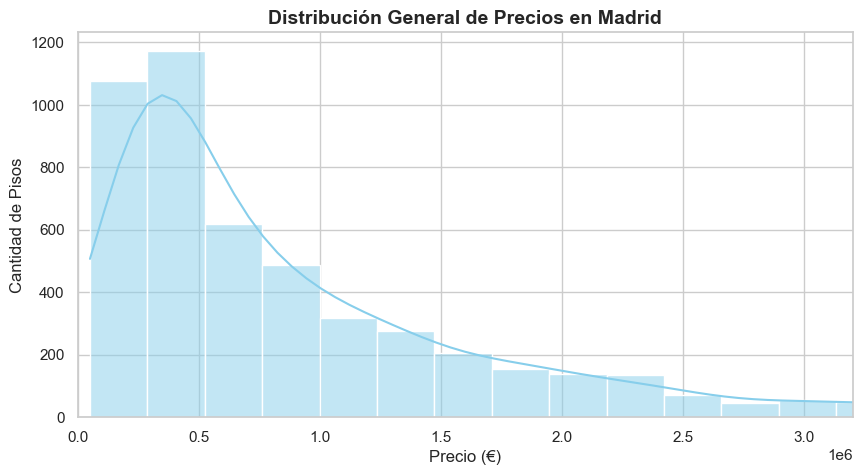

In [4]:
plt.figure(figsize=(10, 5))
sns.histplot(df['precio_limpio'], bins=50, kde=True, color="skyblue")
plt.title('Distribución General de Precios en Madrid', fontsize=14, weight='bold')
plt.xlabel('Precio (€)', fontsize=12)
plt.ylabel('Cantidad de Pisos', fontsize=12)
plt.xlim(0, df['precio_limpio'].quantile(0.95)) # Recortamos el 5% de superlujo para ver bien la campana
plt.show()

### 3. Precio Medio por Metro Cuadrado en cada Barrio
¿Cuáles son los barrios más caros y los más baratos según los datos?

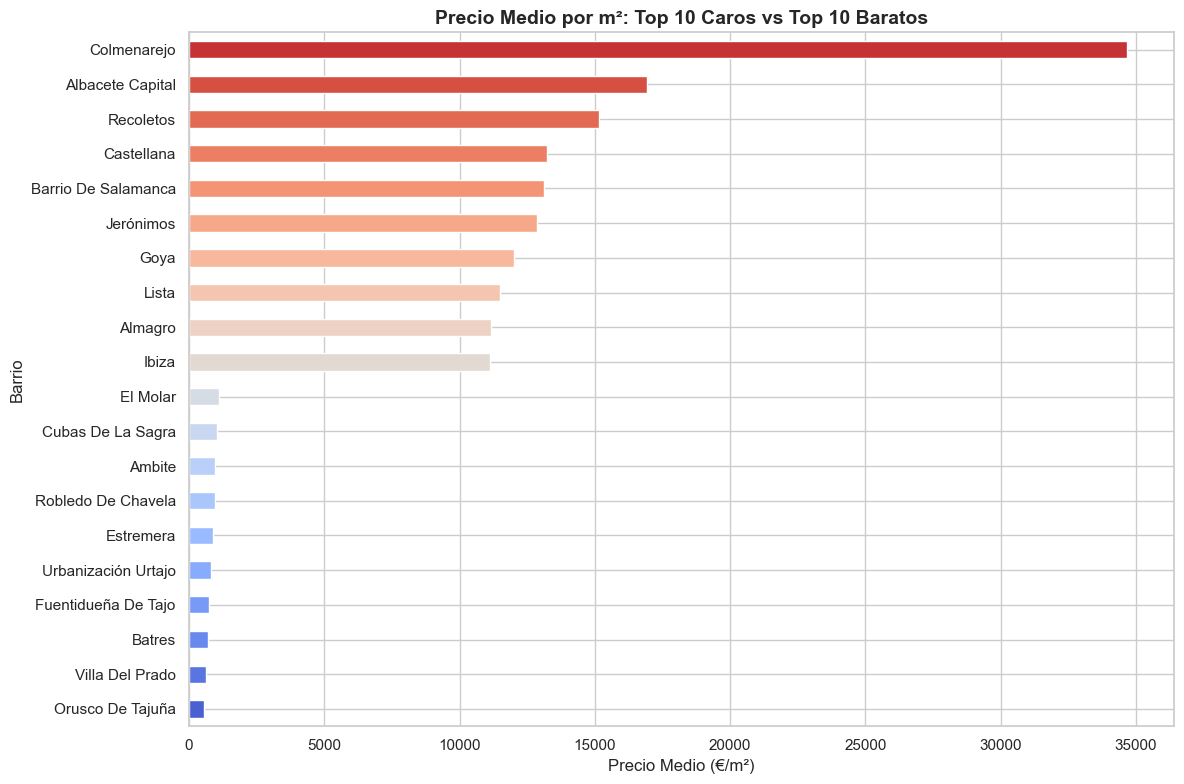

In [5]:
# Agrupar por barrio y calcular la media del precio por m2
precio_barrio = df.groupby('barrio_limpio')['precio_m2'].mean().sort_values(ascending=False)

# Nos quedamos con los 15 más caros y los 15 más baratos para no saturar
top_caros = precio_barrio.head(10)
top_baratos = precio_barrio.tail(10)
barrios_seleccionados = pd.concat([top_caros, top_baratos]).sort_values()

plt.figure(figsize=(12, 8))
barrios_seleccionados.plot(kind='barh', color=sns.color_palette("coolwarm", len(barrios_seleccionados)))
plt.title('Precio Medio por m²: Top 10 Caros vs Top 10 Baratos', fontsize=14, weight='bold')
plt.xlabel('Precio Medio (€/m²)', fontsize=12)
plt.ylabel('Barrio', fontsize=12)
plt.tight_layout()
plt.show()

### 4. El Impacto de los Extras (Feature Engineering)
¿Afecta al precio que el piso tenga piscina, terraza o garaje? Lo que vamos a ver a continuación demuestra el valor real que aporta nuestra extracción de variables.

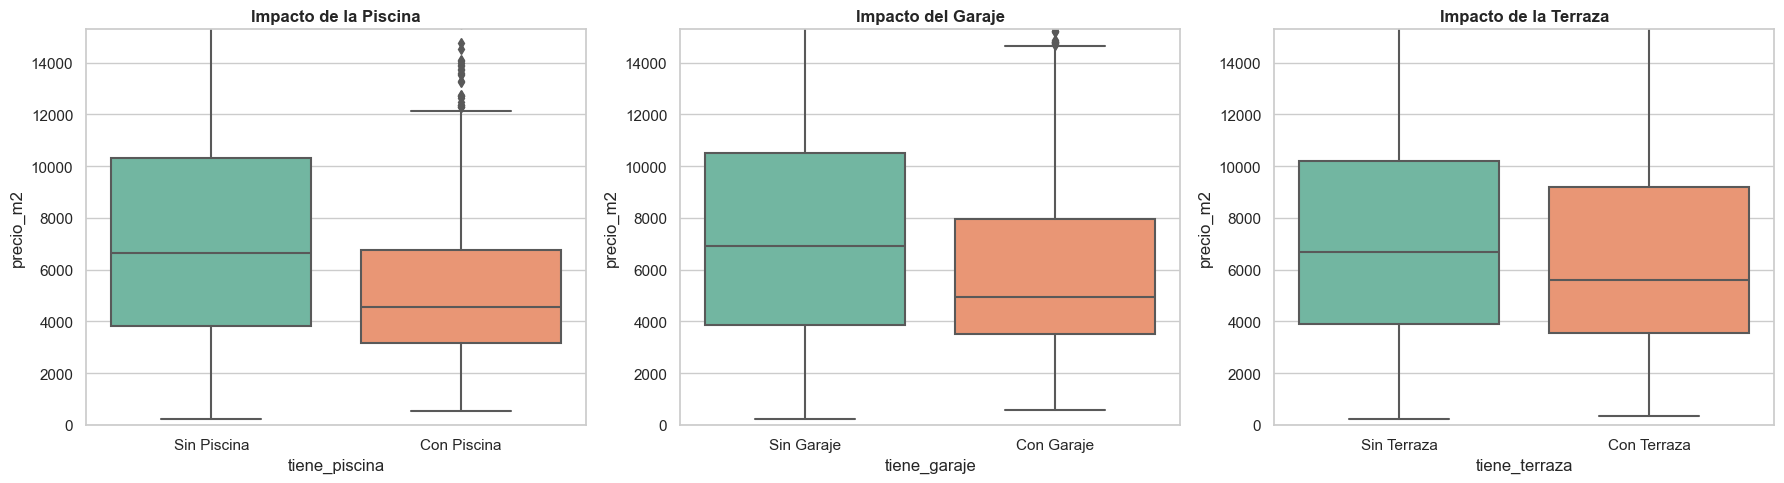

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Piscina
sns.boxplot(x='tiene_piscina', y='precio_m2', data=df, ax=axes[0], palette="Set2")
axes[0].set_title('Impacto de la Piscina', weight='bold')
axes[0].set_xticklabels(['Sin Piscina', 'Con Piscina'])
axes[0].set_ylim(0, df['precio_m2'].quantile(0.95))

# Garaje
sns.boxplot(x='tiene_garaje', y='precio_m2', data=df, ax=axes[1], palette="Set2")
axes[1].set_title('Impacto del Garaje', weight='bold')
axes[1].set_xticklabels(['Sin Garaje', 'Con Garaje'])
axes[1].set_ylim(0, df['precio_m2'].quantile(0.95))

# Terraza
sns.boxplot(x='tiene_terraza', y='precio_m2', data=df, ax=axes[2], palette="Set2")
axes[2].set_title('Impacto de la Terraza', weight='bold')
axes[2].set_xticklabels(['Sin Terraza', 'Con Terraza'])
axes[2].set_ylim(0, df['precio_m2'].quantile(0.95))

plt.tight_layout()
plt.show()

### 5. Matriz de Correlación Matemática
Un vistazo directo a cómo de unidas están las variables entre sí. Un valor cercano a 1 indica una fuerte relación directa.

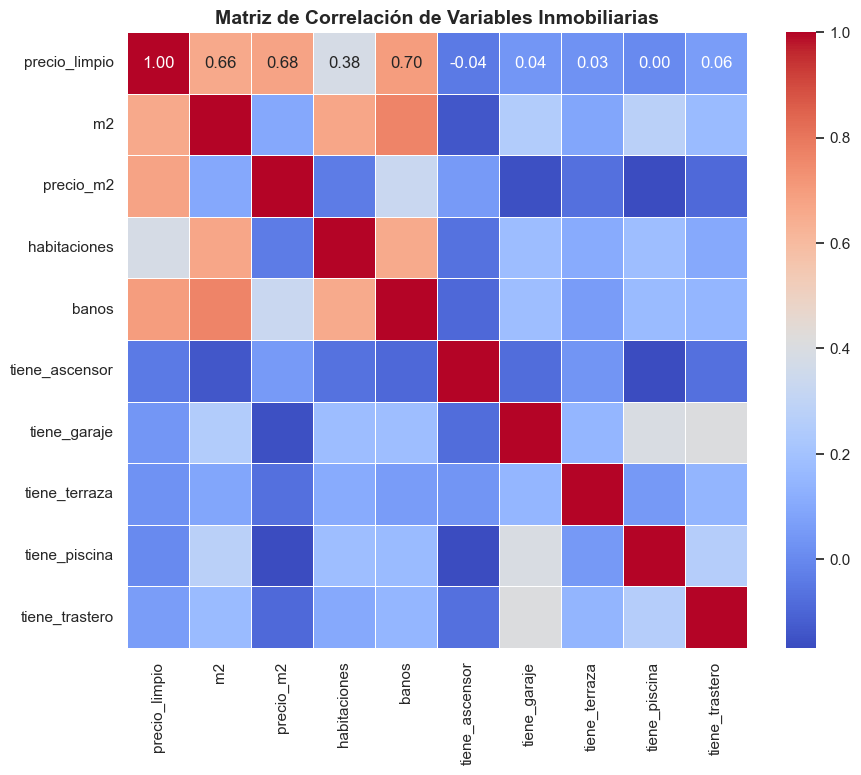

In [7]:
# Seleccionamos solo las variables numericas
variables_numericas = ['precio_limpio', 'm2', 'precio_m2', 'habitaciones', 'banos', 
                       'tiene_ascensor', 'tiene_garaje', 'tiene_terraza', 'tiene_piscina', 'tiene_trastero']
df_num = df[variables_numericas]

# Calculamos la matriz de correlacion (Pearson)
corr_matrix = df_num.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Variables Inmobiliarias', fontsize=14, weight='bold')
plt.show()

### Ver la estructura general y si hay nulos

In [8]:
# Ver información general y columnas
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
print("\n--- Valores nulos por columna ---")
print(df.isnull().sum())

Filas: 5031, Columnas: 26

--- Valores nulos por columna ---
id_inmueble              0
url_origen               0
tipo_inmueble            0
barrio_limpio            0
planta_limpia         1767
precio_limpio            0
m2                       0
precio_m2                0
habitaciones             0
banos                    0
tiene_ascensor           0
tiene_garaje             0
tiene_terraza            0
tiene_piscina            0
tiene_trastero           0
descripcion_limpia       0
img_url_1                0
img_url_2                0
img_url_3                0
img_url_4              182
img_url_5              182
local_img_1             14
local_img_2              1
local_img_3              0
local_img_4            182
local_img_5            182
dtype: int64


### Recuento de pisos por barrio

Total de barrios únicos: 394

Top 10 barrios con más pisos:
barrio_limpio
Goya                    291
Castellana              198
Recoletos               188
Lista                   163
Universidad-Malasaña    152
Embajadores-Lavapiés    141
Justicia-Chueca         117
Palacio                  97
Cortes-Huertas           94
Ibiza                    93
Name: count, dtype: int64


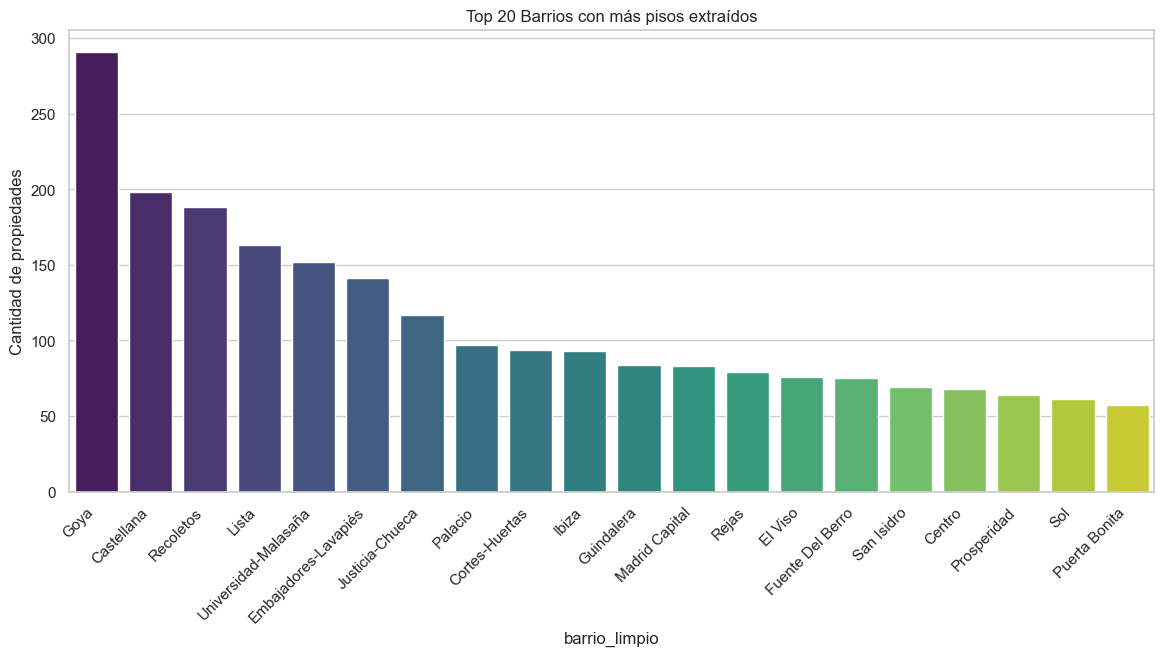

In [9]:
# Conteo de pisos por barrio
conteo_barrios = df['barrio_limpio'].value_counts()
print(f"Total de barrios únicos: {len(conteo_barrios)}")
print("\nTop 10 barrios con más pisos:")
print(conteo_barrios.head(10))

# Gráfico de los 20 barrios con más representación
plt.figure(figsize=(14, 6))
sns.barplot(x=conteo_barrios.head(20).index, y=conteo_barrios.head(20).values, palette="viridis")
plt.title("Top 20 Barrios con más pisos extraídos")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Cantidad de propiedades")
plt.show()

### Revisar las variables visuales (extraídas por Gemini)

Cargadas 781 propiedades etiquetadas.


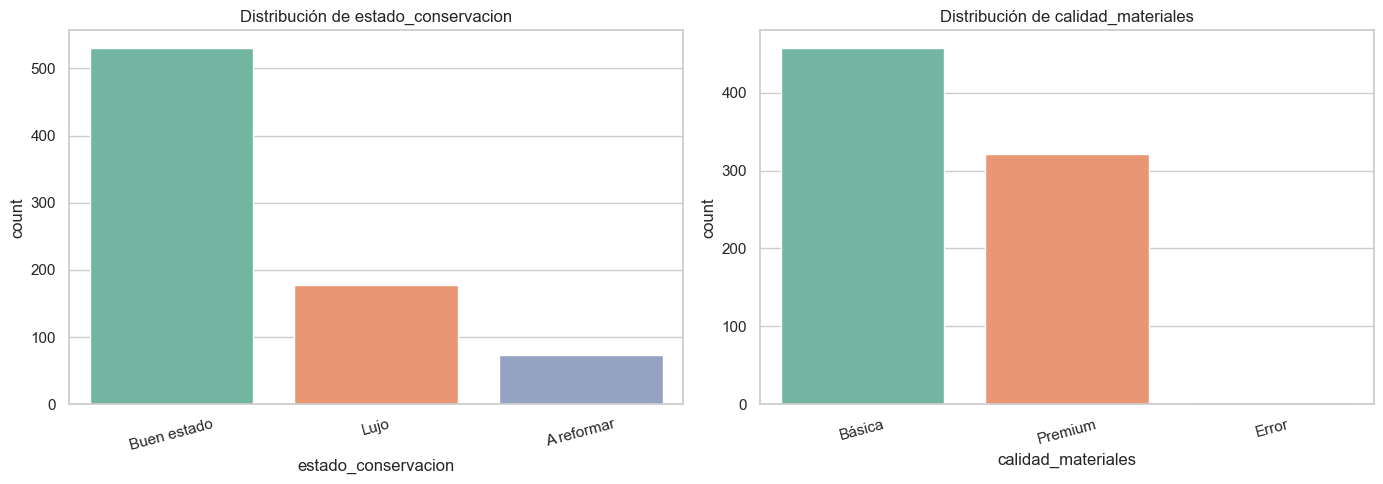

In [10]:
# Primero cargamos el dataset que ya tiene las etiquetas de Gemini
import os
etiquetadas_path = '../data_pipeline/data/processed/propiedades_etiquetadas.csv'
if os.path.exists(etiquetadas_path):
    df_vlm = pd.read_csv(etiquetadas_path)
    print(f"Cargadas {len(df_vlm)} propiedades etiquetadas.")
    
    cols_vlm = ['estado_conservacion', 'calidad_materiales']
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for i, col in enumerate(cols_vlm):
        if col in df_vlm.columns:
            sns.countplot(data=df_vlm, x=col, ax=axes[i], palette="Set2")
            axes[i].set_title(f"Distribución de {col}")
            axes[i].tick_params(axis='x', rotation=15)
    
    plt.tight_layout()
    plt.show()
else:
    print("Todavía no se ha generado el archivo propiedades_etiquetadas.csv")


### 4. Distribución de Precios y Metros Cuadrados
Analizamos cómo se distribuyen los precios totales y por metro cuadrado. Esto nos ayuda a entender si la variable objetivo (`precio_limpio`) tiene una distribución normal o si está sesgada (típico en el mercado inmobiliario).

c:\Users\jorge\OneDrive\Escritorio\Master CEU\TFM v2\venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\jorge\OneDrive\Escritorio\Master CEU\TFM v2\venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


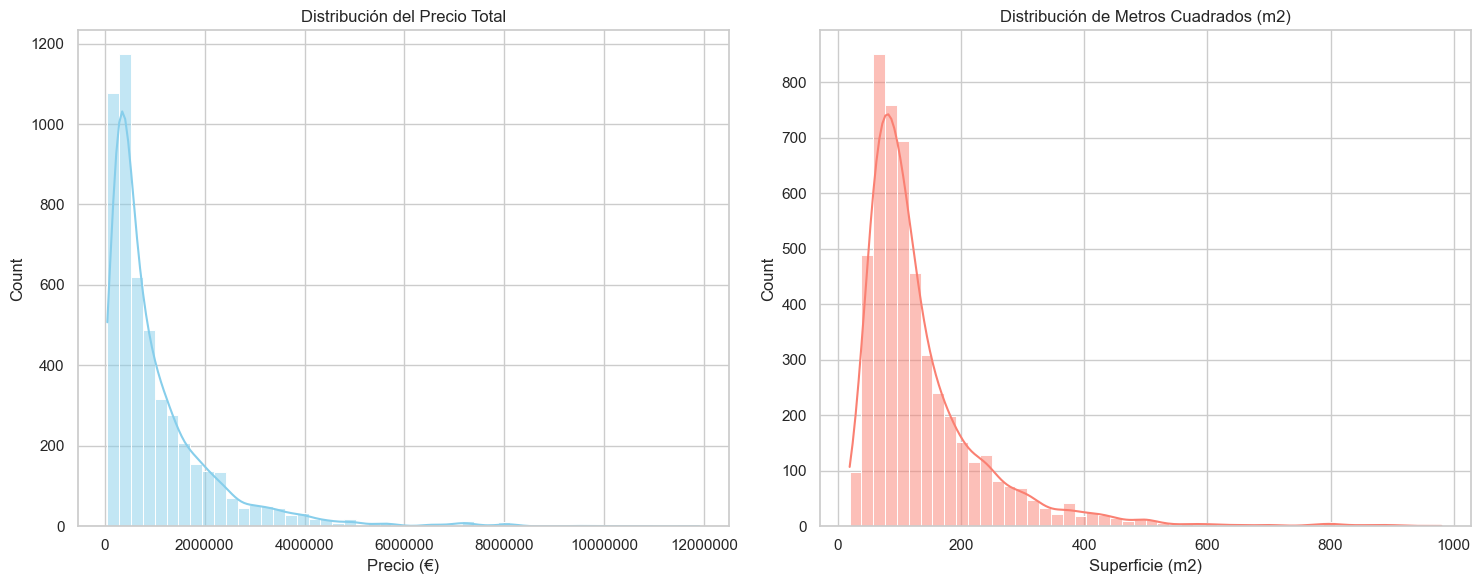

In [11]:
# Gráficos de distribución de Precio y M2
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(df['precio_limpio'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución del Precio Total')
axes[0].set_xlabel('Precio (€)')
# Formatear el eje X para que no salga en notación científica (ej. 1e6)
axes[0].ticklabel_format(style='plain', axis='x')

sns.histplot(df['m2'], bins=50, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribución de Metros Cuadrados (m2)')
axes[1].set_xlabel('Superficie (m2)')

plt.tight_layout()
plt.show()

### 5. Detección y Tratamiento de Outliers (Valores Atípicos)
Los portales inmobiliarios a veces tienen errores tipográficos (ej. un piso de 10 millones de euros por error, o un piso de 5m2). Usaremos el Rango Intercuartílico (IQR) para filtrar estos valores extremos y que no "ensucien" el entrenamiento de nuestra Red Neuronal.

In [12]:
def eliminar_outliers_iqr(dataframe, columna):
    Q1 = dataframe[columna].quantile(0.25)
    Q3 = dataframe[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # Filtramos
    df_filtrado = dataframe[(dataframe[columna] >= limite_inferior) & (dataframe[columna] <= limite_superior)]
    return df_filtrado

# Aplicamos el filtro sobre el precio y sobre los metros cuadrados
df_limpio = df.copy()
print(f"Propiedades originales: {len(df_limpio)}")

df_limpio = eliminar_outliers_iqr(df_limpio, 'precio_limpio')
df_limpio = eliminar_outliers_iqr(df_limpio, 'm2')

print(f"Propiedades tras eliminar outliers: {len(df_limpio)}")
print(f"Se han eliminado {len(df) - len(df_limpio)} posibles valores atípicos o erróneos.")

Propiedades originales: 5031
Propiedades tras eliminar outliers: 4384
Se han eliminado 647 posibles valores atípicos o erróneos.


### 6. Mapa de Calor de Correlaciones
Vamos a ver qué variables (habitaciones, planta, ascensor, piscina...) influyen más a la hora de determinar el `precio_limpio` de un piso. Los valores cercanos a 1 indican una correlación positiva fuerte (si uno sube, el otro también).

c:\Users\jorge\OneDrive\Escritorio\Master CEU\TFM v2\venv\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


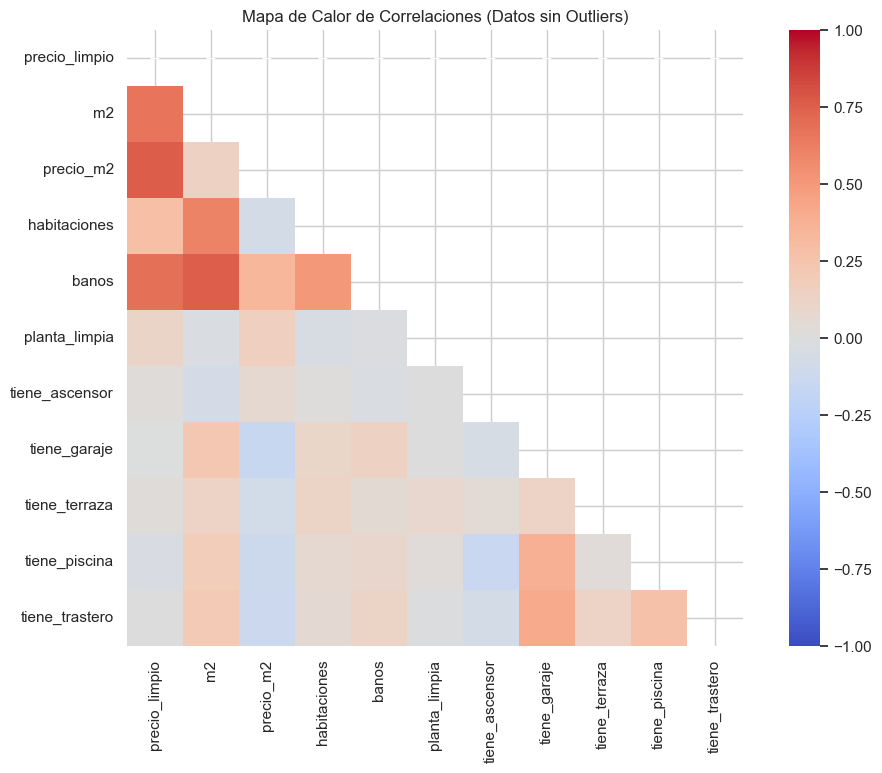

In [13]:
# Seleccionamos solo las variables numéricas para hacer la matriz de correlación
cols_numericas = ['precio_limpio', 'm2', 'precio_m2', 'habitaciones', 'banos', 'planta_limpia', 
                  'tiene_ascensor', 'tiene_garaje', 'tiene_terraza', 'tiene_piscina', 'tiene_trastero']

# Nos aseguramos de que estén en el dataset y sean numéricas
cols_existentes = [c for c in cols_numericas if c in df_limpio.columns]
df_corr = df_limpio[cols_existentes].corr()

plt.figure(figsize=(12, 8))
# mask para ocultar la mitad superior repetida del triángulo
mask = np.triu(np.ones_like(df_corr, dtype=bool))
sns.heatmap(df_corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, center=0, square=True)
plt.title("Mapa de Calor de Correlaciones (Datos sin Outliers)")
plt.show()

### 7. Impacto Combinado: Visión Artificial + Datos Tabulares
Por último, integramos el dataset que tiene las etiquetas extraídas de las imágenes (Gemini) con nuestro dataset ya limpio de outliers, para comprobar si características subjetivas como un "Buen estado" o materiales "Premium" realmente alteran la distribución del precio en el mercado.

Propiedades combinadas con éxito (Tabulares + Visuales): 723


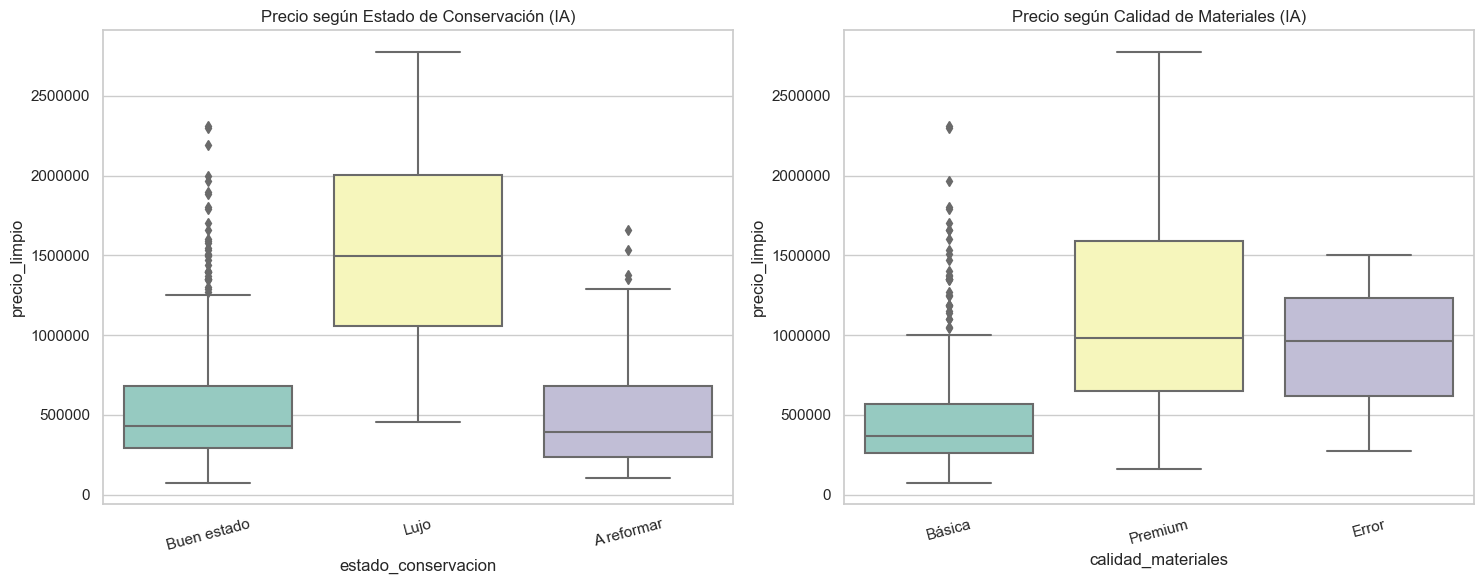

In [14]:
# Unimos las etiquetas de Gemini al dataset sin outliers (usando id_inmueble)
if 'df_vlm' in locals():
    # Hacemos un merge conservando los datos limpios (inner join con lo que haya etiquetado Gemini)
    df_final = pd.merge(df_limpio, df_vlm[['id_inmueble', 'estado_conservacion', 'calidad_materiales']], on='id_inmueble', how='inner')
    
    print(f"Propiedades combinadas con éxito (Tabulares + Visuales): {len(df_final)}")
    
    if len(df_final) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        
        sns.boxplot(data=df_final, x='estado_conservacion', y='precio_limpio', ax=axes[0], palette='Set3')
        axes[0].set_title('Precio según Estado de Conservación (IA)')
        axes[0].tick_params(axis='x', rotation=15)
        # Evitar notación científica en Y
        axes[0].ticklabel_format(style='plain', axis='y')
        
        sns.boxplot(data=df_final, x='calidad_materiales', y='precio_limpio', ax=axes[1], palette='Set3')
        axes[1].set_title('Precio según Calidad de Materiales (IA)')
        axes[1].tick_params(axis='x', rotation=15)
        axes[1].ticklabel_format(style='plain', axis='y')
        
        plt.tight_layout()
        plt.show()
else:
    print("Por favor, ejecuta primero la celda 3 (la que carga df_vlm de propiedades_etiquetadas.csv)")

### Cantidad de Pisos y Casas por Barrio/Ciudad
Para visualizar la distribución geográfica de los inmuebles (exclusivamente pisos y casas), mostramos cuántas propiedades hay disponibles en cada barrio.

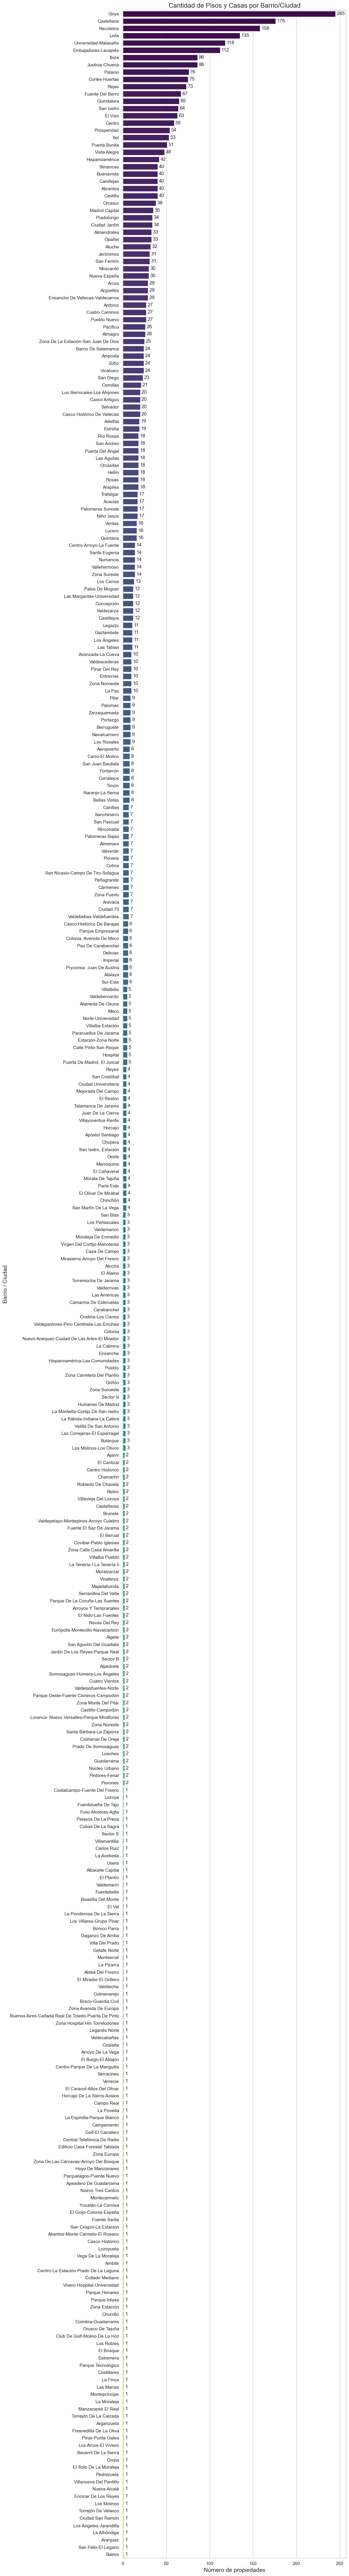

In [15]:
# Filtrar inmuebles que son 'Piso' o 'Casa'
tipos_interes = ['Piso', 'Casa']
df_filtrado = df[df['tipo_inmueble'].isin(tipos_interes)]

# Contar por barrio
conteo_barrios = df_filtrado['barrio_limpio'].value_counts()

# Configurar el tamaño de la figura para que se lean bien todos los barrios (al haber muchos)
alto_figura = max(8, len(conteo_barrios) * 0.25)
plt.figure(figsize=(12, alto_figura))

# Crear la gráfica de barras horizontal
ax = sns.barplot(x=conteo_barrios.values, y=conteo_barrios.index, palette='viridis')

# Añadir el número al final de cada barra
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title('Cantidad de Pisos y Casas por Barrio/Ciudad', fontsize=16)
plt.xlabel('Número de propiedades', fontsize=14)
plt.ylabel('Barrio / Ciudad', fontsize=14)
plt.tight_layout()
plt.show()

### Buscador Inmobiliario Extendido (Corregido)
Buscador HTML con todas las variables físicas y corrección de valores en plantas numéricas.

In [16]:
import pandas as pd
from IPython.display import display, HTML

df_html = pd.read_csv('../data_pipeline/data/processed/propiedades_limpias.csv')
columnas = ['barrio_limpio', 'tipo_inmueble', 'precio_limpio', 'm2', 'precio_m2', 'habitaciones', 'banos', 'planta_limpia', 'tiene_ascensor', 'tiene_garaje', 'tiene_piscina', 'tiene_terraza', 'tiene_trastero']
df_html = df_html.dropna(subset=['barrio_limpio'])
barrios = sorted(df_html['barrio_limpio'].unique())

html = """
<div style="font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; padding: 20px; border: 2px solid #34495e; border-radius: 10px; background-color: #ffffff; color: #000000; overflow-x: auto;">
    <h3 style="margin-top: 0; color: #2c3e50; border-bottom: 2px solid #3498db; padding-bottom: 10px;">🔍 Buscador Nativo de Inmuebles Completo</h3>
    
    <div style="margin-bottom: 20px;">
        <label for="barrio-select" style="font-size: 16px; font-weight: bold; color: #2c3e50;">Elige una ubicación:</label>
        <select id="barrio-select" onchange="filterTable()" style="padding: 8px; font-size: 15px; margin-left: 10px; border: 1px solid #3498db; border-radius: 5px; background-color: #f8f9fa; color: #000000; font-weight: bold; cursor: pointer;">
            <option value="Todos">-- Mostrar los primeros 50 inmuebles --</option>
"""

for b in barrios:
    html += f'<option value="{b}">{b}</option>\n'

html += """
        </select>
    </div>
    
    <div style="max-height: 500px; overflow-y: auto; overflow-x: auto; border: 1px solid #bdc3c7; border-radius: 5px;">
        <table id="inmuebles-table" style="border-collapse: collapse; width: 100%; text-align: center; background-color: #ffffff; color: #000000; font-size: 14px; white-space: nowrap;">
            <thead style="position: sticky; top: 0; background-color: #2c3e50; color: #ffffff; z-index: 1;">
                <tr>
"""

for col in columnas:
    col_name = col.replace('_limpio', '').replace('_limpia', '').replace('tiene_', '').replace('_', ' ').title()
    html += f'<th style="padding: 12px 15px; border-bottom: 2px solid #34495e;">{col_name}</th>'
html += "</tr>\n</thead>\n<tbody>\n"

for i, row in df_html.iterrows():
    bg_color = "#f9f9f9" if i % 2 == 0 else "#ffffff"
    html += f'<tr class="data-row" data-barrio="{row["barrio_limpio"]}" style="display: none; background-color: {bg_color}; border-bottom: 1px solid #ecf0f1;">'
    for col in columnas:
        val = row[col]
        if pd.isna(val):
            val_str = "-"
        elif col.startswith('tiene_'):
            val_str = "✅" if (val == True or str(val) == '1.0' or str(val).lower() in ['si', 'sí']) else "❌"
        elif col in ['precio_limpio', 'precio_m2']:
            val_str = f"{float(val):,.0f} €".replace(',', '.')
        else:
            val_str = str(val).replace('.0', '') if str(val).endswith('.0') else str(val)
        html += f'<td style="padding: 12px 15px; color: #222222; font-weight: 500;">{val_str}</td>'
    html += "</tr>\n"

html += """
            </tbody>
        </table>
    </div>
</div>

<style>
    #inmuebles-table tbody tr:hover {
        background-color: #e8f4f8 !important;
    }
</style>

<script>
function filterTable() {
    var select = document.getElementById("barrio-select");
    var barrio = select.value;
    var rows = document.getElementsByClassName("data-row");
    var count = 0;
    
    for (var i = 0; i < rows.length; i++) {
        if (barrio === "Todos") {
            if (count < 50) {
                rows[i].style.display = "";
                count++;
            } else {
                rows[i].style.display = "none";
            }
        } else {
            if (rows[i].getAttribute("data-barrio") === barrio) {
                rows[i].style.display = "";
            } else {
                rows[i].style.display = "none";
            }
        }
    }
}
filterTable();
</script>
"""

display(HTML(html))


Barrio,Tipo Inmueble,Precio,M2,Precio M2,Habitaciones,Banos,Planta,Ascensor,Garaje,Piscina,Terraza,Trastero
Trafalgar,Piso,7.000.000 €,233,30.043 €,2,4,1,❌,❌,❌,❌,❌
Guindalera,Piso,730.000 €,91,8.022 €,2,1,1,✅,✅,❌,✅,❌
Portazgo,Piso,362.000 €,94,3.851 €,3,2,4,❌,❌,❌,✅,❌
Casco Histórico De Barajas,Piso,350.000 €,75,4.667 €,3,1,-,❌,✅,❌,❌,❌
Arcos,Piso,230.000 €,61,3.770 €,2,1,1,❌,❌,❌,❌,❌
Casco Histórico De Vallecas,Dúplex,346.500 €,138,2.511 €,3,2,2,❌,❌,❌,✅,✅
Casco Histórico De Barajas,Piso,259.000 €,51,5.078 €,2,1,-,❌,❌,❌,❌,❌
Guindalera,Piso,590.000 €,80,7.375 €,2,1,4,✅,❌,❌,❌,❌
Embajadores-Lavapiés,Piso,385.000 €,60,6.417 €,2,2,-,✅,❌,❌,❌,❌
Vista Alegre,Piso,231.000 €,97,2.381 €,3,1,3,❌,❌,❌,✅,❌
